In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import met_brewer as mb
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerTuple

%matplotlib inline

Note that the data given contain $\bar{R}(t)$ which is the mean over $N$ cells over time and $\sigma_{R}(t)$ which is the standard deviation over $N$ cells over time. 

We normalize the data such that we can relate the normalized measurements to the ratio of phosphorylated to unphosphorylated sensor (following the advice of Greenwald et al. 2014).
First we compute the min and max of $\bar{R}(t)$. Then we compute normalized ratio, which is defined
$$
R_{\rm norm}(t) \equiv \frac{\bar{R}(t) - R_{\rm min}}{R_{\rm max} - R_{\rm min}},
$$
which is equivalent to normalizing the data from each cell to min and max of the average of all cells.

Next, we need to normalize the standard deviation. We use the following formula
$$
\sigma^2_{R_{\rm norm}}(t) = \frac{\sigma^2_{R}(t)}{(R_{\rm max} - R_{\rm min})^2}
$$
which comes from computing the variance of the normalized data.

In [2]:
# ==========================================
# Helper functions
# ==========================================

def make_df(time, mean_col, std_col):
    return pd.DataFrame({
        'Time (min)': time,
        'MEAN': pd.to_numeric(mean_col, errors='coerce'),
        'STD': pd.to_numeric(std_col, errors='coerce')
    }).dropna()

def trim_and_shift(df, t_drug):
    """Keep only t >= t_drug and shift so t_drug becomes t=0."""
    trimmed = df[df['Time (min)'] >= t_drug].copy()
    trimmed['Time (min)'] = trimmed['Time (min)'] - t_drug
    return trimmed.reset_index(drop=True)

def normalize_minmax(mean, std, ref_mean=None):
    if ref_mean is None:
        ref_mean = mean
    rmin, rmax = ref_mean.min(), ref_mean.max()
    return (mean - rmin) / (rmax - rmin), std / (rmax - rmin)


## HeLaAMPKAR3 + LKB1wt Data (260307)

In [3]:
###############################################
#   Load HeLaAMPKAR3 + LKB1wt data (260307)
###############################################
hela_raw = pd.read_excel('../../../AMPKARkey_data/260307_HeLaAMPKAR3_LKB1wt_kd.xlsx',
                          sheet_name='Sheet1', skiprows=2, header=None)
hela_time = pd.to_numeric(hela_raw.iloc[:, 0])

# Column layout:
#   0:     TIME_min
#   1-3:   LKB1wt_Iono  (DRUG, MEAN_CY, STD_CY)
#   4-6:   LKB1kd_Iono  (DRUG, MEAN_CY, STD_CY)
#   7-9:   LKB1wt_2DG   (DRUG, MEAN_CY, STD_CY)
#   10-12: LKB1kd_2DG   (DRUG, MEAN_CY, STD_CY)
#   13-17: RCamp_Iono   (DRUG, MEAN_CY, STD_CY, MEAN_RFPnorm, STD_RFPnorm)
#   18-22: RCamp_2DG    (DRUG, MEAN_CY, STD_CY, MEAN_RFPnorm, STD_RFPnorm)

# Drug addition times
t_2dg = 5.0
t_iono = 6.5

# AMPKAR data: LKB1kd and LKB1wt (4 conditions)
lkb1kd_iono_df = trim_and_shift(make_df(hela_time, hela_raw.iloc[:, 5], hela_raw.iloc[:, 6]), t_iono)
lkb1kd_2dg_df = trim_and_shift(make_df(hela_time, hela_raw.iloc[:, 11], hela_raw.iloc[:, 12]), t_2dg)
lkb1wt_iono_df = trim_and_shift(make_df(hela_time, hela_raw.iloc[:, 2], hela_raw.iloc[:, 3]), t_iono)
lkb1wt_2dg_df = trim_and_shift(make_df(hela_time, hela_raw.iloc[:, 8], hela_raw.iloc[:, 9]), t_2dg)

# RCamp (calcium) data — for future calcium-CaMKK2 module
rcamp_iono_calcium_df = trim_and_shift(make_df(hela_time, hela_raw.iloc[:, 16], hela_raw.iloc[:, 17]), t_iono)
rcamp_2dg_calcium_df = trim_and_shift(make_df(hela_time, hela_raw.iloc[:, 21], hela_raw.iloc[:, 22]), t_2dg)

###############################################
#   Min-max normalization
#   LKB1kd normalized to WT's min/max (same scale per drug)
###############################################
# WT: each condition normalized to its own min/max
norm_lkb1wt_iono, norm_lkb1wt_iono_sd = normalize_minmax(lkb1wt_iono_df['MEAN'], lkb1wt_iono_df['STD'])
norm_lkb1wt_2dg, norm_lkb1wt_2dg_sd = normalize_minmax(lkb1wt_2dg_df['MEAN'], lkb1wt_2dg_df['STD'])

# LKB1kd: normalized using WT's min/max as reference (preserves relative amplitude)
norm_lkb1kd_iono, norm_lkb1kd_iono_sd = normalize_minmax(lkb1kd_iono_df['MEAN'], lkb1kd_iono_df['STD'], ref_mean=lkb1wt_iono_df['MEAN'])
norm_lkb1kd_2dg, norm_lkb1kd_2dg_sd = normalize_minmax(lkb1kd_2dg_df['MEAN'], lkb1kd_2dg_df['STD'], ref_mean=lkb1wt_2dg_df['MEAN'])

# RCamp (calcium): each condition normalized to its own min/max
norm_rcamp_iono_ca, norm_rcamp_iono_ca_sd = normalize_minmax(rcamp_iono_calcium_df['MEAN'], rcamp_iono_calcium_df['STD'])
norm_rcamp_2dg_ca, norm_rcamp_2dg_ca_sd = normalize_minmax(rcamp_2dg_calcium_df['MEAN'], rcamp_2dg_calcium_df['STD'])

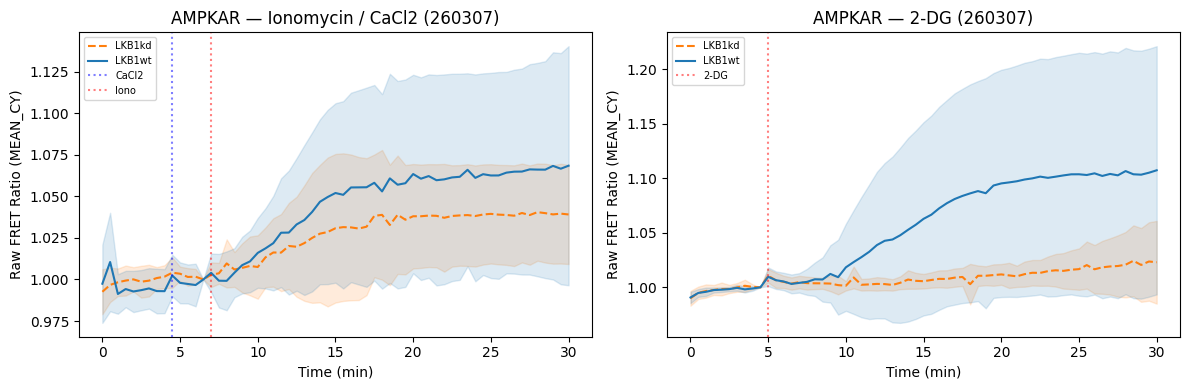

In [4]:
# ==========================================
# Plot raw 260307 data (full time series including pre-drug baseline)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Ionomycin ---
ax = axes[0]
for label, mean_col, std_col, color, ls in [
    ('LKB1kd', 5, 6, 'tab:orange', '--'),
    ('LKB1wt', 2, 3, 'tab:blue', '-'),
]:
    m = pd.to_numeric(hela_raw.iloc[:, mean_col], errors='coerce')
    s = pd.to_numeric(hela_raw.iloc[:, std_col], errors='coerce')
    ax.plot(hela_time, m, color=color, linestyle=ls, label=label)
    ax.fill_between(hela_time, m - s, m + s, alpha=0.15, color=color)
ax.axvline(4.5, color='blue', linestyle=':', alpha=0.5, label='CaCl2')
ax.axvline(7.0, color='red', linestyle=':', alpha=0.5, label='Iono')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Raw FRET Ratio (MEAN_CY)')
ax.set_title('AMPKAR — Ionomycin / CaCl2 (260307)')
ax.legend(fontsize=7)

# --- 2-DG ---
ax = axes[1]
for label, mean_col, std_col, color, ls in [
    ('LKB1kd', 11, 12, 'tab:orange', '--'),
    ('LKB1wt', 8, 9, 'tab:blue', '-'),
]:
    m = pd.to_numeric(hela_raw.iloc[:, mean_col], errors='coerce')
    s = pd.to_numeric(hela_raw.iloc[:, std_col], errors='coerce')
    ax.plot(hela_time, m, color=color, linestyle=ls, label=label)
    ax.fill_between(hela_time, m - s, m + s, alpha=0.15, color=color)
ax.axvline(5.0, color='red', linestyle=':', alpha=0.5, label='2-DG')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Raw FRET Ratio (MEAN_CY)')
ax.set_title('AMPKAR — 2-DG (260307)')
ax.legend(fontsize=7)

fig.tight_layout()
fig.savefig('../../../AMPKARkey_data/raw_plot_260307.pdf')

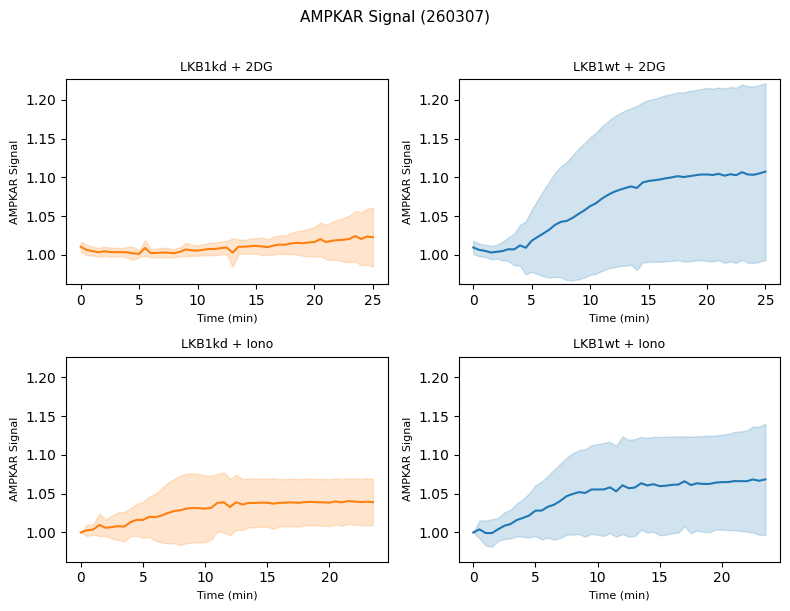

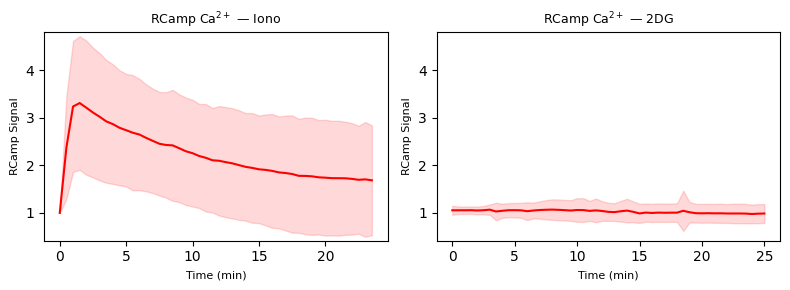

In [5]:
# ==========================================
# Plot trimmed raw 260307 AMPKAR data (2 conditions x 2 drugs)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

ampkar_specs = [
    # --- 2DG (top row) ---
    (0, 0, lkb1kd_2dg_df, 'LKB1kd + 2DG', 'tab:orange'),
    (0, 1, lkb1wt_2dg_df, 'LKB1wt + 2DG', 'tab:blue'),
    # --- Iono (bottom row) ---
    (1, 0, lkb1kd_iono_df, 'LKB1kd + Iono', 'tab:orange'),
    (1, 1, lkb1wt_iono_df, 'LKB1wt + Iono', 'tab:blue'),
]

for r, c, df, title, color in ampkar_specs:
    ax = axes[r, c]
    ax.plot(df['Time (min)'], df['MEAN'], color=color)
    ax.fill_between(df['Time (min)'], df['MEAN'] - df['STD'], df['MEAN'] + df['STD'], alpha=0.2, color=color)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Time (min)', fontsize=8)
    ax.set_ylabel('AMPKAR Signal', fontsize=8)

# Shared ylim across all AMPKAR subplots
ampkar_dfs = [lkb1kd_2dg_df, lkb1wt_2dg_df, lkb1kd_iono_df, lkb1wt_iono_df]
ampkar_ymin = min((df['MEAN'] - df['STD']).min() for df in ampkar_dfs)
ampkar_ymax = max((df['MEAN'] + df['STD']).max() for df in ampkar_dfs)
margin = 0.02 * (ampkar_ymax - ampkar_ymin)
for ax in axes.flat:
    ax.set_ylim(ampkar_ymin - margin, ampkar_ymax + margin)

fig.suptitle('AMPKAR Signal (260307)', fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig('../../../AMPKARkey_data/raw_plot_260307_ampkar.pdf')

# ==========================================
# Plot trimmed raw 260307 RCamp (calcium) data separately
# ==========================================
fig_ca, axes_ca = plt.subplots(1, 2, figsize=(8, 3))

for ax, df, title in [
    (axes_ca[0], rcamp_iono_calcium_df, 'RCamp Ca$^{2+}$ — Iono'),
    (axes_ca[1], rcamp_2dg_calcium_df, 'RCamp Ca$^{2+}$ — 2DG'),
]:
    ax.plot(df['Time (min)'], df['MEAN'], color='red')
    ax.fill_between(df['Time (min)'], df['MEAN'] - df['STD'], df['MEAN'] + df['STD'], alpha=0.15, color='red')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Time (min)', fontsize=8)
    ax.set_ylabel('RCamp Signal', fontsize=8)

# Shared ylim for calcium plots
rcamp_dfs = [rcamp_2dg_calcium_df, rcamp_iono_calcium_df]
rcamp_ymin = min((df['MEAN'] - df['STD']).min() for df in rcamp_dfs)
rcamp_ymax = max((df['MEAN'] + df['STD']).max() for df in rcamp_dfs)
rmargin = 0.02 * (rcamp_ymax - rcamp_ymin)
for ax in axes_ca:
    ax.set_ylim(rcamp_ymin - rmargin, rcamp_ymax + rmargin)

fig_ca.tight_layout()
fig_ca.savefig('../../../AMPKARkey_data/raw_plot_260307_calcium.pdf')

In [6]:
# ==========================================
# Save 260307 AMPKAR data as .npz files (LKB1kd and LKB1wt only)
# ==========================================
savedir = '../../../AMPKARkey_data/'

hela_ampkar_experiments = {
    'LKB1kd_Iono': (lkb1kd_iono_df, norm_lkb1kd_iono, norm_lkb1kd_iono_sd),
    'LKB1kd_2DG': (lkb1kd_2dg_df, norm_lkb1kd_2dg, norm_lkb1kd_2dg_sd),
    'LKB1wt_Iono': (lkb1wt_iono_df, norm_lkb1wt_iono, norm_lkb1wt_iono_sd),
    'LKB1wt_2DG': (lkb1wt_2dg_df, norm_lkb1wt_2dg, norm_lkb1wt_2dg_sd),
}

for name, (df, nm, ns) in hela_ampkar_experiments.items():
    fname = savedir + 'HeLaAMPKAR3_260307_' + name + '.npz'
    np.savez(fname,
             times=df['Time (min)'].to_numpy(),
             mean=nm.to_numpy(),
             std=ns.to_numpy(),
             std_constant=ns.mean())
    print(f'Saved {fname}')

Saved ../../../AMPKARkey_data/HeLaAMPKAR3_260307_LKB1kd_Iono.npz
Saved ../../../AMPKARkey_data/HeLaAMPKAR3_260307_LKB1kd_2DG.npz
Saved ../../../AMPKARkey_data/HeLaAMPKAR3_260307_LKB1wt_Iono.npz
Saved ../../../AMPKARkey_data/HeLaAMPKAR3_260307_LKB1wt_2DG.npz


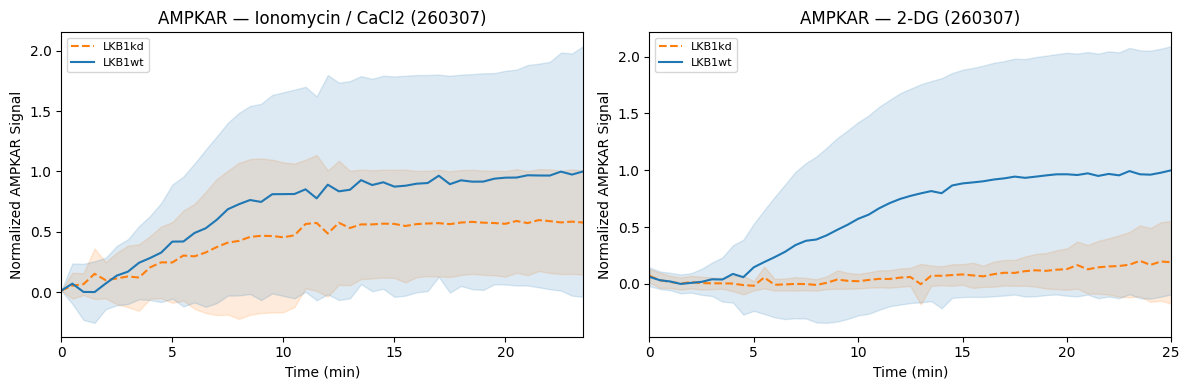

In [7]:
# ==========================================
# Plot normalized 260307 AMPKAR data: LKB1kd vs LKB1wt per drug
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'LKB1kd': 'tab:orange', 'LKB1wt': 'tab:blue'}
linestyles = {'LKB1kd': '--', 'LKB1wt': '-'}

# --- Iono ---
ax = axes[0]
for label, df, nm, ns in [
    ('LKB1kd', lkb1kd_iono_df, norm_lkb1kd_iono, norm_lkb1kd_iono_sd),
    ('LKB1wt', lkb1wt_iono_df, norm_lkb1wt_iono, norm_lkb1wt_iono_sd),
]:
    ax.plot(df['Time (min)'], nm, color=colors[label], linestyle=linestyles[label], label=label)
    ax.fill_between(df['Time (min)'], nm - ns, nm + ns, alpha=0.15, color=colors[label])
ax.set_xlabel('Time (min)')
ax.set_ylabel('Normalized AMPKAR Signal')
ax.set_title('AMPKAR — Ionomycin / CaCl2 (260307)')
ax.legend(fontsize=8)
ax.set_xlim([0, lkb1kd_iono_df['Time (min)'].max()])

# --- 2-DG ---
ax = axes[1]
for label, df, nm, ns in [
    ('LKB1kd', lkb1kd_2dg_df, norm_lkb1kd_2dg, norm_lkb1kd_2dg_sd),
    ('LKB1wt', lkb1wt_2dg_df, norm_lkb1wt_2dg, norm_lkb1wt_2dg_sd),
]:
    ax.plot(df['Time (min)'], nm, color=colors[label], linestyle=linestyles[label], label=label)
    ax.fill_between(df['Time (min)'], nm - ns, nm + ns, alpha=0.15, color=colors[label])
ax.set_xlabel('Time (min)')
ax.set_ylabel('Normalized AMPKAR Signal')
ax.set_title('AMPKAR — 2-DG (260307)')
ax.legend(fontsize=8)
ax.set_xlim([0, lkb1kd_2dg_df['Time (min)'].max()])

fig.tight_layout()
fig.savefig('../../../AMPKARkey_data/normalized_plot_260307.pdf')